# 🔧 Notebook 02 — Preprocesamiento de Texto

Construimos y validamos el pipeline de limpieza de texto **paso a paso**.

El texto crudo de YouTube tiene ruido que engaña al modelo: URLs, menciones, caracteres raros (`\xa0`), contracciones rotas (`don t`).
Antes de vectorizar necesitamos texto limpio y normalizado.

### Herramientas
- **`re`** → expresiones regulares para limpiar ruido estructural
- **`NLTK`** → lista curada de 179 stopwords en inglés
- **`spaCy`** → lematización con modelo de lenguaje real `en_core_web_sm`
- **`MLflow`** → registrar qué configuración de preprocesamiento usamos

## 0. Imports y configuración

Cargamos todo desde el YAML. Ningún valor hardcodeado en el notebook.

In [2]:
import re
import sys
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import nltk
import spacy
from nltk.corpus import stopwords
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Ruta raiz — 
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'Python       : {sys.version.split()[0]}')

/home/under/miniconda3/envs/py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT : /mnt/c/Users/under/Documents/F5/3_Projects/Project_9_Equipo3/Project_YT
Python       : 3.10.20


In [3]:
# Carga de configuracion desde YAML
CONFIG_PATH = PROJECT_ROOT / 'configs' / 'features.yaml'

with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

prep_cfg = config['preprocessing']
print('Configuracion de preprocesamiento:')
for k, v in prep_cfg.items():
    print(f'  {k}: {v}')

Configuracion de preprocesamiento:
  lowercase: True
  remove_urls: True
  remove_mentions: True
  remove_emojis: True
  remove_special_chars: True
  remove_stopwords: True
  lemmatize: True
  min_token_length: 2
  language: en
  custom_stopwords: ['youtube', 'video', 'watch', 'like', 'comment', 'channel', 'stefan', 'peggy', 'masri', 'ferguson', 'cigar', 'hubbard']


In [4]:
# Descargar recursos NLTK
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# Cargar modelo spaCy
# Si no lo tienes instalado: python -m spacy download en_core_web_sm
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

print(f"spaCy  : {nlp.meta['name']} v{nlp.meta['version']}")
print(f'NLTK   : {len(stopwords.words("english"))} stopwords en ingles')

spaCy  : core_web_sm v3.8.0
NLTK   : 198 stopwords en ingles


## 1. Carga de datos

Las rutas vienen del YAML de pipeline, no se escriben a mano.

In [5]:
PIPELINE_PATH = PROJECT_ROOT / 'configs' / 'pipeline.yaml'

with open(PIPELINE_PATH) as f:
    pipeline_cfg = yaml.safe_load(f)

DATA_PATH  = PROJECT_ROOT / pipeline_cfg['data']['raw_path']
TEXT_COL   = pipeline_cfg['data']['text_column']
TARGET_BIN = pipeline_cfg['data']['target_binary']
SUBLABELS  = pipeline_cfg['data']['target_multilabel']

df = pd.read_csv(DATA_PATH)
print(f'Dataset  : {df.shape}')
print(f'Texto    : "{TEXT_COL}"')
print(f'Target   : "{TARGET_BIN}"')
print(f'Sublabels: {SUBLABELS}')
print()
print('Muestra texto crudo:')
for t in df[TEXT_COL].sample(3, random_state=42):
    print(f'  -> {repr(t[:100])}')

Dataset  : (1000, 15)
Texto    : "Text"
Target   : "IsToxic"
Sublabels: ['IsAbusive', 'IsProvocative', 'IsHatespeech', 'IsRacist', 'IsObscene']

Muestra texto crudo:
  -> "You call yourself an anarchist but defend a cop shooting an unarmed civilian. I'm highly disappointe"
  -> 'My mother told me the same thing.\xa0 God Bless this woman.'
  -> 'Love it I same the saem thing Go Peggy!  #stupid \xa0\nYa Killing ya selves more quicker than\xa0 STLPD cou'


## 2. Pipeline paso a paso

Construimos cada función por separado para entender su efecto antes de encadenarlas.

```
texto raw
  → [1] lowercase
  → [2] regex: URLs, @menciones, \xa0, contracciones rotas, números
  → [3] spaCy: tokenización + lematización
  → [4] NLTK: filtrado stopwords + tokens cortos + puntuación
  → texto limpio
```

In [6]:
# ── PASO 1: Lowercase ──
# Por que: 'BLACK' y 'black' son la misma palabra.
# Sin esto el modelo aprende 'BLACK' y 'black' como features distintas.

def to_lowercase(text: str) -> str:
    """Convierte el texto a minusculas."""
    return str(text).lower()

# Validacion visual
print('PASO 1 — Lowercase')
print('-' * 65)
for ex in df[TEXT_COL].sample(3, random_state=1).tolist():
    print(f'  ANTES  : {ex[:60]}')
    print(f'  DESPUES: {to_lowercase(ex)[:60]}')
    print()

PASO 1 — Lowercase
-----------------------------------------------------------------
  ANTES  : Stephan, Thank you for the video. It takes all the available
  DESPUES: stephan, thank you for the video. it takes all the available

  ANTES  : Body cams should also air what the police run into day to da
  DESPUES: body cams should also air what the police run into day to da

  ANTES  : This is a really sad story. Someone is killed for no reason,
  DESPUES: this is a really sad story. someone is killed for no reason,



In [7]:
# ── PASO 2: Limpieza con Regex ────────────────────────────────────────────
# Por que regex: hay ruido sistematico en comentarios de YouTube.
# El EDA mostro: \xa0 embebidos, saltos de linea, URLs, @menciones.


def clean_regex(text: str) -> str:
    """Limpieza con expresiones regulares."""
    # URLs completas
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Menciones @usuario
    text = re.sub(r'@\w+', '', text)
    # Saltos de linea y tabulaciones -> espacio
    text = re.sub(r'[\n\t\r]', ' ', text)
    # Caracteres no-ASCII: \xa0, emojis, caracteres especiales
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    # Apostrofes: "don't" -> "dont", "it's" -> "its"
    text = re.sub(r"'", '', text)
    # Numeros solos sin contexto lexico util
    text = re.sub(r'\b\d+\b', '', text)
    # Espacios multiples -> uno solo
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# Validacion con casos problematicos reales del dataset (ejemplo)
print('PASO 2 — Limpieza Regex')
print('-' * 65)
test_cases = [
    'Check this out http://youtube.com/watch?v=abc123 ok?',
    'Hey @username you\'re so stupid\xa0\xa0 really',
    'dont\nyou see?\n\nThis is wrong!!!',
    'He has 100 guns and 50 knives',
]
for tc in test_cases:
    print(f'  ANTES  : {repr(tc)}')
    print(f'  DESPUES: {repr(clean_regex(tc))}')
    print()

PASO 2 — Limpieza Regex
-----------------------------------------------------------------
  ANTES  : 'Check this out http://youtube.com/watch?v=abc123 ok?'
  DESPUES: 'Check this out ok?'

  ANTES  : "Hey @username you're so stupid\xa0\xa0 really"
  DESPUES: 'Hey youre so stupid really'

  ANTES  : 'dont\nyou see?\n\nThis is wrong!!!'
  DESPUES: 'dont you see? This is wrong!!!'

  ANTES  : 'He has 100 guns and 50 knives'
  DESPUES: 'He has guns and knives'



In [8]:
# ── PASO 3 + 4: Lematizacion con spaCy + filtrado con NLTK ───────────────
#
# Por que spaCy para LEMATIZAR:
#   Conoce gramatica inglesa real. // 'running' -> 'run' | 'cops' -> 'cop' | 'better' -> 'good'

# Por que NLTK para STOPWORDS:
#   Lista curada de 179 palabras funcionales (the, is, at, which...)
#   Mas explicita y facil de personalizar que la lista interna de spaCy


STOP_WORDS = set(stopwords.words('english'))

# Stopwords custom: palabras tematicas sin valor discriminante
CUSTOM_STOPWORDS = set(config['preprocessing']['custom_stopwords'])
STOP_WORDS = STOP_WORDS | CUSTOM_STOPWORDS

MIN_TOKEN_LEN = prep_cfg.get('min_token_length', 2)

def lemmatize_and_filter(text: str) -> str:
    """Lematiza con spaCy y filtra stopwords con NLTK."""
    doc = nlp(text)     # Separación de palabras
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_punct                    # sin puntuacion
        and not token.is_space                   # sin espacios
        and len(token.text) >= MIN_TOKEN_LEN     # tokens de al menos 2 chars
        and token.lemma_ not in STOP_WORDS       # sin stopwords
    ]
    return ' '.join(tokens)


# Validacion: ver exactamente que hace la lematizacion (ejemplo)
print('PASO 3+4 — Lematizacion (spaCy) + Filtrado (NLTK)')
print('-' * 65)
test_texts = [
    'black people are being killed by cops',
    'you are so stupid and racist thug',
    'running faster than the police officers',
    'these cops are criminals and killers',
    'Hi, stefan'
]
for tt in test_texts:
    result = lemmatize_and_filter(tt)
    print(f'  ANTES  : {tt}')
    print(f'  DESPUES: {result}')
    print()

PASO 3+4 — Lematizacion (spaCy) + Filtrado (NLTK)
-----------------------------------------------------------------
  ANTES  : black people are being killed by cops
  DESPUES: black people kill cop

  ANTES  : you are so stupid and racist thug
  DESPUES: stupid racist thug

  ANTES  : running faster than the police officers
  DESPUES: run fast police officer

  ANTES  : these cops are criminals and killers
  DESPUES: cop criminal killer

  ANTES  : Hi, stefan
  DESPUES: hi



In [9]:
# ── PIPELINE COMPLETO ──

def preprocess_text(text: str) -> str:
    """
    Pipeline completo de preprocesamiento NLP.

    Pasos:
        1. lowercase
        2. limpieza regex (URLs, menciones, chars especiales)
        3. lematizacion con spaCy
        4. filtrado stopwords con NLTK

    """
    text = to_lowercase(text)
    text = clean_regex(text)
    text = lemmatize_and_filter(text)
    return text

# Verificacion con ejemplos reales del dataset
print('PIPELINE COMPLETO — Ejemplos reales del dataset')
print('=' * 70)
for _, row in df.sample(6, random_state=42).iterrows():
    label = 'TOXICO    ' if row[TARGET_BIN] else 'NO TOXICO '
    print(f'[{label}]')
    print(f'  CRUDO  : {row[TEXT_COL][:100]}')
    print(f'  LIMPIO : {preprocess_text(row[TEXT_COL])[:100]}')
    print()

PIPELINE COMPLETO — Ejemplos reales del dataset
[NO TOXICO ]
  CRUDO  : You call yourself an anarchist but defend a cop shooting an unarmed civilian. I'm highly disappointe
  LIMPIO : call anarchist defend cop shoot unarmed civilian highly disappointed beginning refer square know blu

[NO TOXICO ]
  CRUDO  : My mother told me the same thing.  God Bless this woman.
  LIMPIO : mother tell I thing god bless woman

[NO TOXICO ]
  CRUDO  : Love it I same the saem thing Go Peggy!  #stupid  
Ya Killing ya selves more quicker than  STLPD cou
  LIMPIO : love saem thing go stupid ya kill ya self quick stlpd could ever wakeup

[TOXICO    ]
  CRUDO  : Next time they do that, line up some cars and start making burnout smoke to "riot gas" them. Non let
  LIMPIO : next time line car start make burnout smoke riot gas non lethal eficient double check actualy non le

[NO TOXICO ]
  CRUDO  : He was Robbing the Store and Being a Big Man .
If you Play with Fire you Will Get Burnt .?
The Polic
  LIMPIO : ro

## 3. Aplicar el pipeline al dataset completo

Procesamos las 1000 filas y validamos que no haya pérdida de información crítica.

In [10]:
print('Procesando dataset completo...')
df['clean_text'] = df[TEXT_COL].apply(preprocess_text)
print(f'Completado: {len(df)} comentarios procesados')

Procesando dataset completo...
Completado: 1000 comentarios procesados


In [11]:
# Estadisticas antes vs despues
df['tokens_raw']   = df[TEXT_COL].str.split().str.len()
df['tokens_clean'] = df['clean_text'].str.split().str.len()

print(f"{'':20} {'CRUDO':>8} {'LIMPIO':>8} {'REDUCCION':>11}")
print('-' * 52)
for stat in ['mean', 'median', 'min', 'max']:
    raw   = getattr(df['tokens_raw'],   stat)()
    clean = getattr(df['tokens_clean'], stat)()
    pct   = (1 - clean / raw) * 100 if raw > 0 else 0
    print(f'  {stat:18} {raw:8.1f} {clean:8.1f} {pct:10.1f}%')

print()
empty_after = (df['tokens_clean'] == 0).sum()
print(f'Comentarios vacios tras limpieza : {empty_after}')

                        CRUDO   LIMPIO   REDUCCION
----------------------------------------------------
  mean                   33.8     16.5       51.2%
  median                 19.0      9.0       52.6%
  min                     1.0      1.0        0.0%
  max                   815.0    373.0       54.2%

Comentarios vacios tras limpieza : 0


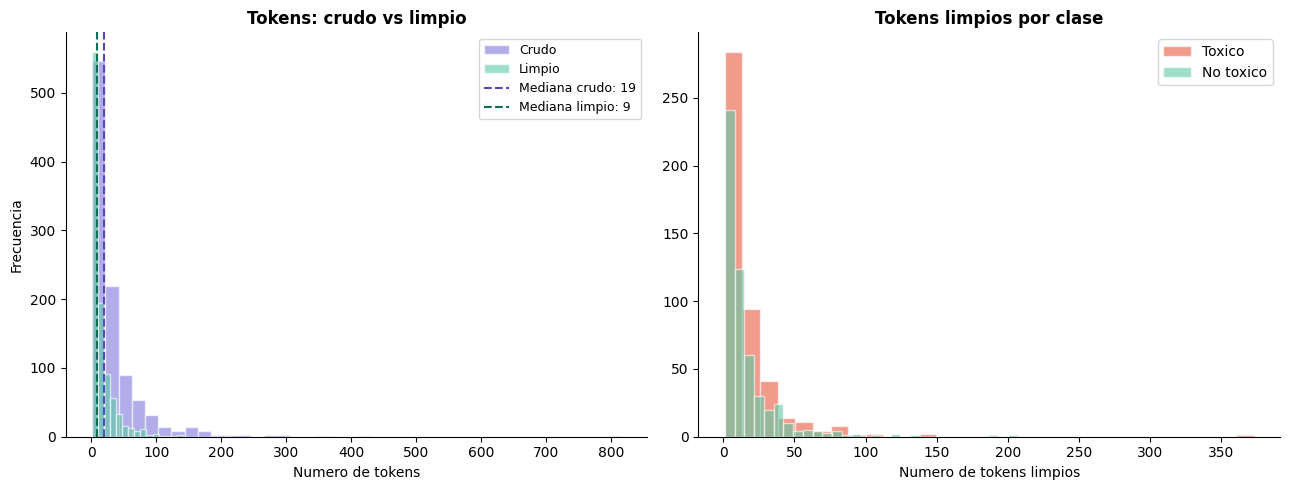

💾 Guardado en reports/07_tokens_comparativa.png


In [12]:
# Visualizacion: distribucion tokens antes vs despues
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Comparativa global
axes[0].hist(df['tokens_raw'],   bins=40, alpha=0.6, label='Crudo',
             color='#7F77DD', edgecolor='white')
axes[0].hist(df['tokens_clean'], bins=40, alpha=0.6, label='Limpio',
             color='#5DCAA5', edgecolor='white')
axes[0].axvline(df['tokens_raw'].median(),   color='#534AB7',
                linestyle='--', lw=1.5, label=f'Mediana crudo: {df["tokens_raw"].median():.0f}')
axes[0].axvline(df['tokens_clean'].median(), color='#0F6E56',
                linestyle='--', lw=1.5, label=f'Mediana limpio: {df["tokens_clean"].median():.0f}')
axes[0].set_title('Tokens: crudo vs limpio', fontweight='bold')
axes[0].set_xlabel('Numero de tokens')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=9)

# Por clase
for clase, color in [('Toxico', '#E8593C'), ('No toxico', '#5DCAA5')]:
    mask = df[TARGET_BIN] == (clase == 'Toxico')
    axes[1].hist(df.loc[mask, 'tokens_clean'], bins=30, alpha=0.6,
                 label=clase, color=color, edgecolor='white')
axes[1].set_title('Tokens limpios por clase', fontweight='bold')
axes[1].set_xlabel('Numero de tokens limpios')
axes[1].legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'v2' / '07_tokens_comparativa.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardado en reports/07_tokens_comparativa.png')

In [13]:
# Casos problematicos: comentarios con menos de 3 tokens tras limpieza
# Son comentarios que casi desaparecen -> hay que revisarlos
short_clean = df[df['tokens_clean'] < 3]
print(f'Comentarios con < 3 tokens tras limpieza: {len(short_clean)}')
print()
for _, row in short_clean.head(6).iterrows():
    label = 'TOXICO' if row[TARGET_BIN] else 'NO TOXICO'
    print(f'  [{label}]')
    print(f'    CRUDO  : {row[TEXT_COL][:80]}')
    print(f'    LIMPIO : "{row["clean_text"]}"')
    print()

Comentarios con < 3 tokens tras limpieza: 106

  [NO TOXICO]
    CRUDO  : I agree with the protestor.
    LIMPIO : "agree protestor"

  [TOXICO]
    CRUDO  : I think ,he kill him
    LIMPIO : "think kill"

  [NO TOXICO]
    CRUDO  : 1 word: Provocateur........
    LIMPIO : "word provocateur"

  [NO TOXICO]
    CRUDO  : I LIKE TURTLES!
    LIMPIO : "turtle"

  [TOXICO]
    CRUDO  : CNN is such Bullcrap!
    LIMPIO : "cnn bullcrap"

  [TOXICO]
    CRUDO  : You all are some dumb as people
    LIMPIO : "dumb people"



## 4. Registro en MLflow

Guardamos exactamente qué configuración usamos.
Si mañana cambiamos `min_token_length` o las custom stopwords,
podremos comparar qué configuración produjo mejores métricas al modelar.

> Para ver el dashboard: `mlflow ui` desde la raíz del proyecto.

> mlflow ui --backend-store-uri file:./mlruns --port 5001 

In [14]:
# ── Configuración MLflow ──
MLFLOW_DIR      = PROJECT_ROOT / 'mlruns'
EXPERIMENT_NAME = 'Youtube_project_data'

mlflow.set_tracking_uri(f"file:{MLFLOW_DIR}")
mlflow.set_experiment(EXPERIMENT_NAME)


with mlflow.start_run(run_name='preprocessing_v2'):

    # Params: que configuracion usamos
    mlflow.log_param('spacy_model',       'en_core_web_sm')
    mlflow.log_param('nltk_stopwords',    'english')
    mlflow.log_param('custom_stopwords',  list(CUSTOM_STOPWORDS))
    mlflow.log_param('min_token_length',  MIN_TOKEN_LEN)
    mlflow.log_param('remove_urls',       prep_cfg['remove_urls'])
    mlflow.log_param('remove_mentions',   prep_cfg['remove_mentions'])
    mlflow.log_param('lemmatize',         prep_cfg['lemmatize'])

    # Metrics: que produce este preprocesamiento
    reduction = (1 - df['tokens_clean'].mean() / df['tokens_raw'].mean()) * 100
    mlflow.log_metric('avg_tokens_raw',       round(df['tokens_raw'].mean(), 2))
    mlflow.log_metric('avg_tokens_clean',     round(df['tokens_clean'].mean(), 2))
    mlflow.log_metric('median_tokens_clean',  float(df['tokens_clean'].median()))
    mlflow.log_metric('token_reduction_pct',  round(reduction, 2))
    mlflow.log_metric('empty_after_clean',    int(empty_after))
    mlflow.log_metric('short_texts_lt3',      len(short_clean))

    # Artefactos: archivos que produce
    out_csv = PROJECT_ROOT / 'data' / 'processed' / 'v2' /'comments_preprocessed.csv'
    df[['CommentId', TEXT_COL, 'clean_text', TARGET_BIN] + SUBLABELS].to_csv(
        out_csv, index=False
    )
    mlflow.log_artifact(str(out_csv))
    mlflow.log_artifact(str(PROJECT_ROOT / 'reports' / 'v2' / '07_tokens_comparativa.png'))
    mlflow.log_artifact(str(CONFIG_PATH))

    run_id = mlflow.active_run().info.run_id
    print(f'MLflow run registrado')
    print(f'  Run ID     : {run_id}')
    print(f'  Experimento: Youtube_project_data')
    print(f'  Ver UI     : mlflow ui --backend-store-uri file://{MLFLOW_DIR}')

MLflow run registrado
  Run ID     : ed40c8fba662435bbafb563c40b2a75b
  Experimento: Youtube_project_data
  Ver UI     : mlflow ui --backend-store-uri file:///mnt/c/Users/under/Documents/F5/3_Projects/Project_9_Equipo3/Project_YT/mlruns


## 5. Conclusiones y decisiones

In [15]:
reduction = (1 - df['tokens_clean'].mean() / df['tokens_raw'].mean()) * 100

print(f"""
CONCLUSIONES — PREPROCESAMIENTO
{'='*55}
Pipeline aplicado:
  1. lowercase
  2. regex: URLs, @menciones, \\xa0, apostrofes, numeros
  3. spaCy: lematizacion (en_core_web_sm)
  4. NLTK: stopwords english + custom

Resultado:
  Reduccion tokens  : {reduction:.1f}%
  Tokens mediana    : {df['tokens_clean'].median():.0f} (antes: {df['tokens_raw'].median():.0f})
  Comentarios vacios: {empty_after}

Decisiones clave:
  NO quitados: black, white, police, cop
    -> EDA mostro que aparecen en ambas clases con contexto distinto
    -> el modelo necesita verlas para aprender por bigrams
  SI quitados: youtube, video, watch, like, comment, channel
    -> ruido tematico sin valor discriminante
  spaCy para lemma, no NLTK Stemmer
    -> stemmer corta letras, lemma entiende gramatica

""")


CONCLUSIONES — PREPROCESAMIENTO
Pipeline aplicado:
  1. lowercase
  2. regex: URLs, @menciones, \xa0, apostrofes, numeros
  3. spaCy: lematizacion (en_core_web_sm)
  4. NLTK: stopwords english + custom

Resultado:
  Reduccion tokens  : 51.2%
  Tokens mediana    : 9 (antes: 19)
  Comentarios vacios: 0

Decisiones clave:
  NO quitados: black, white, police, cop
    -> EDA mostro que aparecen en ambas clases con contexto distinto
    -> el modelo necesita verlas para aprender por bigrams
  SI quitados: youtube, video, watch, like, comment, channel
    -> ruido tematico sin valor discriminante
  spaCy para lemma, no NLTK Stemmer
    -> stemmer corta letras, lemma entiende gramatica


